# EDA - PPE Detection Dataset

Exploratory Data Analysis for the personal protective equipment (PPE) detection project.

**Dataset:** [PPE Kit Detection - Kaggle](https://www.kaggle.com/datasets/ketakichalke/ppe-kit-detection-construction-site-workers)

**Format:** YOLO (normalized bounding boxes, one `.txt` file per image)

**Important note:** the original `data.yaml` from Kaggle had `nc: 9` but listed 10 class names.
The investigation from Step 2 showed that there are actually **11 classes** (ids 0-10) in the labels.
The missing class (id 10) was VISUALLY identified as "hands without gloves" and named `NO_Gloves`.
This notebook starts from the already-corrected `data.yaml`.

In [32]:
import glob
import os
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# paths relative to this notebook (notebooks/ -> project root -> data_raw)
DATA_ROOT = "../data_raw"
YAML_PATH = "../data.yaml"
SPLITS = ["train", "val", "test"]

## 1. Load configuration (`data.yaml`) and classes

In [33]:
with open(YAML_PATH) as f:
    data_config = yaml.safe_load(f)

CLASS_NAMES = data_config["names"]
NUM_CLASSES = data_config["nc"]

print(f"Number of classes (nc): {NUM_CLASSES}")
print("Class name:")
for cls_id, name in CLASS_NAMES.items():
    print(f"  {cls_id}: {name}")

Number of classes (nc): 11
Class name:
  0: Helmet
  1: Safety_Vest
  2: Safety_goggles
  3: Safety_shoes
  4: NO_helmet
  5: NO_Vest
  6: NO_goggles
  7: No_SafetyShoes
  8: Person
  9: Slippers
  10: NO_Gloves


## 2. General inventory - number of images and labels per split

In [34]:
def list_images(split):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.webp", "*.jfif")
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(DATA_ROOT, split, "images", ext)))
    return files

def list_labels(split):
    return glob.glob(os.path.join(DATA_ROOT, split, "labels", "*.txt"))

inventory = []
for split in SPLITS:
    imgs = list_images(split)
    lbls = list_labels(split)
    inventory.append({
        "split": split,
        "num_images": len(imgs),
        "num_labels": len(lbls),
    })

df_inventory = pd.DataFrame(inventory)
df_inventory["percentage"] = (df_inventory["num_images"] / df_inventory["num_images"].sum() * 100).round(1)
df_inventory

,split,num_images,num_labels,percentage
0,train,10870,10870,70.0
1,val,3100,3100,20.0
2,test,1552,1552,10.0


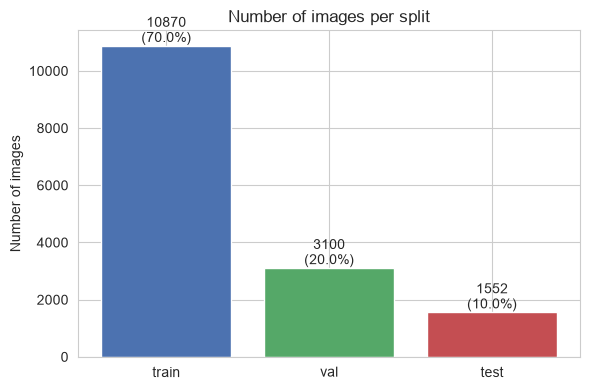

In [35]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_inventory["split"], df_inventory["num_images"], color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_title("Number of images per split")
ax.set_ylabel("Number of images")
for i, v in enumerate(df_inventory["num_images"]):
    ax.text(i, v, f"{v}\n({df_inventory['percentage'][i]}%)", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 3. Image resolution

Checking whether images have consistent dimensions (useful for deciding `imgsz` during training).

In [36]:
# sample - check a subset (500 img) of train, to keep it fast
sample_imgs = list_images("train")[:500]
resolutions = []
for path in sample_imgs:
    img = cv2.imread(path)
    if img is not None:
        h, w = img.shape[:2]
        resolutions.append((w, h))

df_res = pd.DataFrame(resolutions, columns=["width", "height"])
print(f"Sample analyzed: {len(df_res)} images")
print(f"Width  - min: {df_res.width.min()}, max: {df_res.width.max()}, mean: {df_res.width.mean():.0f}")
print(f"Height - min: {df_res.height.min()}, max: {df_res.height.max()}, mean: {df_res.height.mean():.0f}")
print(f"\nNumber of distinct resolutions: {df_res.drop_duplicates().shape[0]}")
df_res.value_counts().head(10)

Sample analyzed: 500 images
Width  - min: 136, max: 4032, mean: 1660
Height - min: 102, max: 4160, mean: 977

Number of distinct resolutions: 46


width  height
1920   1080      341
1280   720        43
612    408        31
4032   3024       14
500    333        13
       375         7
       334         6
       332         3
450    300         2
500    331         2
Name: count, dtype: int64

## 4. Class distribution (Class imbalance)

Counting how many times every class shows up in lables from `train/`.

In [37]:
def count_classes(split):
    counts = Counter()
    for label_path in list_labels(split):
        with open(label_path) as f:
            for line in f:
                line = line.strip()
                if line:
                    cls_id = int(line.split()[0])
                    counts[cls_id] += 1
    return counts

class_counts_train = count_classes("train")

df_classes = pd.DataFrame([
    {"class_id": cid, "name": CLASS_NAMES[cid], "count": class_counts_train.get(cid, 0)}
    for cid in sorted(CLASS_NAMES.keys())
]).sort_values("count", ascending=False)

df_classes

,class_id,name,count
0,0,Helmet,43196
8,8,Person,41745
5,5,NO_Vest,35112
3,3,Safety_shoes,26297
4,4,NO_helmet,7966
1,1,Safety_Vest,2792
6,6,NO_goggles,2297
7,7,No_SafetyShoes,1982
10,10,NO_Gloves,967
9,9,Slippers,738


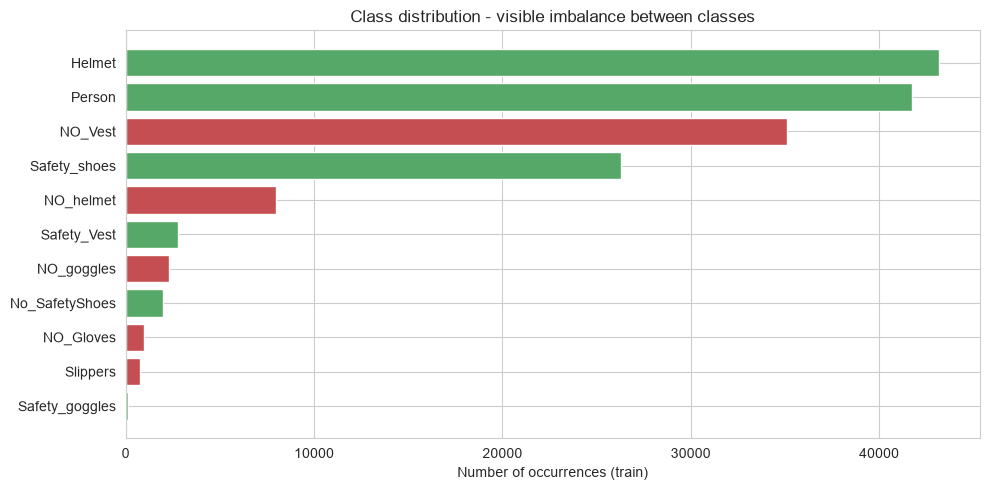

Note: the 'compliant' classes (Helmet, Person, Safety_shoes) dominate,
while Safety_goggles has the fewest examples - risk of poor performance on this class.


In [38]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#C44E52" if "NO" in n or n == "Slippers" else "#55A868" for n in df_classes["name"]]
ax.barh(df_classes["name"], df_classes["count"], color=colors)
ax.set_xlabel("Number of occurrences (train)")
ax.set_title("Class distribution - visible imbalance between classes")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Note: the 'compliant' classes (Helmet, Person, Safety_shoes) dominate,")
print("while Safety_goggles has the fewest examples - risk of poor performance on this class.")

## 5. Missing values / data errors check

- images without a corresponding label file
- empty label files (no annotations at all)
- invalid bounding boxes (coordinates outside the [0, 1] range, zero width/height)

In [39]:
def check_data_quality(split):
    img_files = list_images(split)
    img_basenames = {os.path.splitext(os.path.basename(p))[0] for p in img_files}
    label_files = list_labels(split)
    label_basenames = {os.path.splitext(os.path.basename(p))[0] for p in label_files}

    images_without_label = img_basenames - label_basenames
    labels_without_image = label_basenames - img_basenames

    empty_labels = 0
    invalid_boxes = []
    for label_path in label_files:
        with open(label_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        if len(lines) == 0:
            empty_labels += 1
        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                invalid_boxes.append((label_path, "incomplete line"))
                continue
            _, xc, yc, bw, bh = parts[:5]
            xc, yc, bw, bh = float(xc), float(yc), float(bw), float(bh)
            if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 <= bw <= 1 and 0 <= bh <= 1):
                invalid_boxes.append((label_path, "coordinates outside [0,1]"))
            if bw <= 0 or bh <= 0:
                invalid_boxes.append((label_path, "zero width/height"))

    return {
        "split": split,
        "images_without_label": len(images_without_label),
        "labels_without_image": len(labels_without_image),
        "empty_labels": empty_labels,
        "invalid_bounding_boxes": len(invalid_boxes),
    }

quality_report = [check_data_quality(s) for s in SPLITS]
df_quality = pd.DataFrame(quality_report)
df_quality

,split,images_without_label,labels_without_image,empty_labels,invalid_bounding_boxes
0,train,0,0,32,0
1,val,0,0,0,0
2,test,0,0,32,0


**Interpretation:** if all columns are 0 (or very close to 0), the data is structurally
clean and we can continue without additional cleaning steps. If large values appear,
a decision is needed: remove those files, or fix them manually, before Step 6 (pipeline).

## 6. Bounding box characteristics

Aspect ratio, relative size, and number of objects per image.

In [40]:
box_records = []
objects_per_image = []

for label_path in list_labels("train"):
    with open(label_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    objects_per_image.append(len(lines))
    for line in lines:
        parts = line.split()
        cls_id = int(parts[0])
        xc, yc, bw, bh = map(float, parts[1:5])
        box_records.append({
            "class_id": cls_id,
            "name": CLASS_NAMES[cls_id],
            "width": bw,
            "height": bh,
            "area": bw * bh,
            "aspect_ratio": bw / bh if bh > 0 else 0,
        })

df_boxes = pd.DataFrame(box_records)
df_boxes.describe()

,class_id,width,height,area,aspect_ratio
count,163238.000000,163238.000000,163238.000000,163238.000000,163238.000000
mean,4.088062,0.031758,0.069686,0.007423,0.560002
std,3.056708,0.071242,0.101425,0.046223,0.351776
min,0.000000,0.002401,0.002282,0.000005,0.052840
25%,0.000000,0.011703,0.018069,0.000225,0.318489
50%,5.000000,0.017336,0.036903,0.000620,0.510084
75%,8.000000,0.027634,0.074889,0.002272,0.733056
max,10.000000,1.000000,1.000000,1.000000,9.605658


array([<Axes: title={'center': 'Number of objects per image'}, xlabel='Number of objects', ylabel='Number of images'>,
       <Axes: title={'center': 'Relative object size\n(area normalized to image)'}>],
      dtype=object)

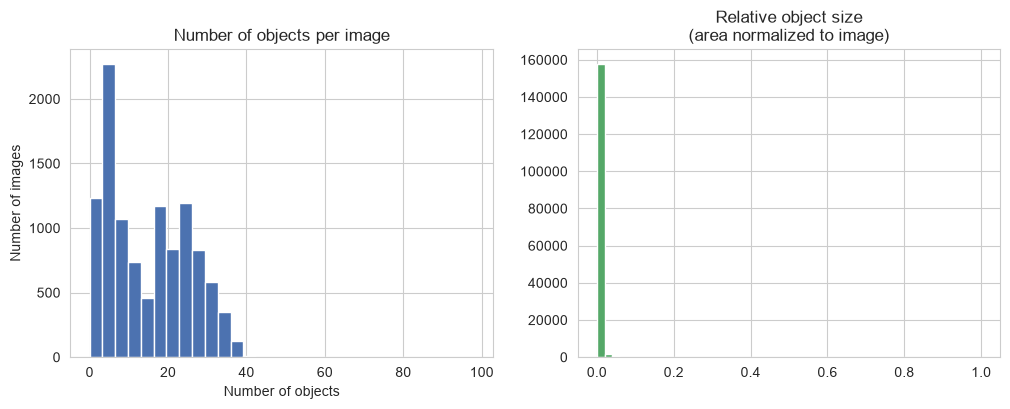

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(objects_per_image, bins=30, color="#4C72B0")
axes[0].set_title("Number of objects per image")
axes[0].set_xlabel("Number of objects")
axes[0].set_ylabel("Number of images")

axes[1].hist(df_boxes["area"], bins=50, color="#55A868")
axes[1].set_title("Relative object size\n(area normalized to image)")
axes

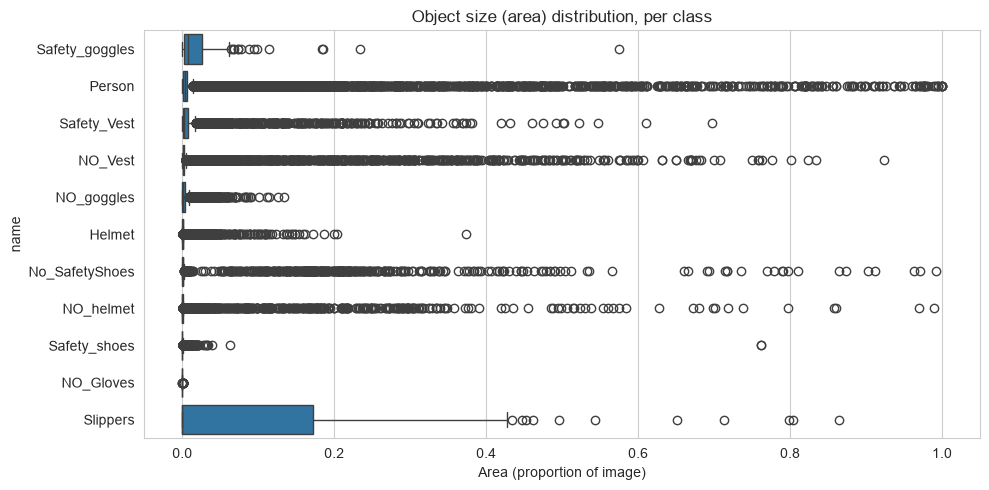

In [42]:
# mean object size (area), per class - some classes (e.g. goggles) are
# systematically smaller -> harder to detect
fig, ax = plt.subplots(figsize=(10, 5))
order = df_boxes.groupby("name")["area"].median().sort_values(ascending=False).index
sns.boxplot(data=df_boxes, y="name", x="area", order=order, ax=ax)
ax.set_title("Object size (area) distribution, per class")
ax.set_xlabel("Area (proportion of image)")
plt.tight_layout()
plt.show()

## 7. Correlations - class co-occurrence

How often two classes appear together in the same image (e.g. `Person` + `Helmet`).

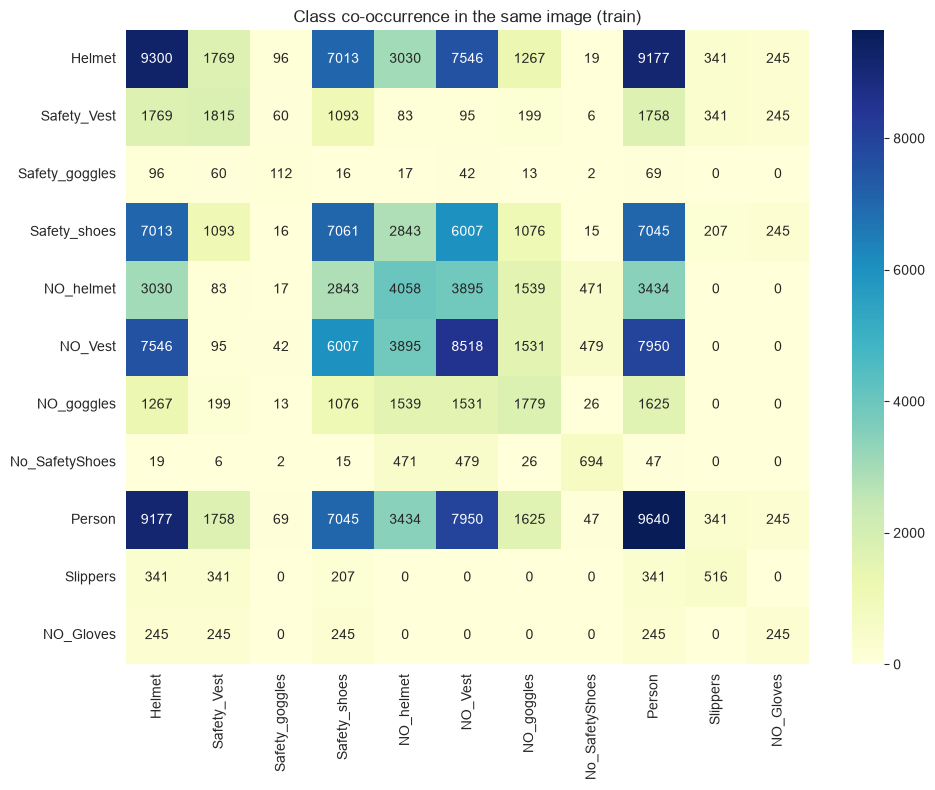

In [43]:
class_ids_sorted = sorted(CLASS_NAMES.keys())
co_occurrence = pd.DataFrame(0, index=class_ids_sorted, columns=class_ids_sorted)

for label_path in list_labels("train"):
    with open(label_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    classes_in_image = set(int(l.split()[0]) for l in lines)
    for c1 in classes_in_image:
        for c2 in classes_in_image:
            co_occurrence.loc[c1, c2] += 1

co_occurrence.index = [CLASS_NAMES[i] for i in co_occurrence.index]
co_occurrence.columns = [CLASS_NAMES[i] for i in co_occurrence.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Class co-occurrence in the same image (train)")
plt.tight_layout()
plt.show()

**Interpretation:** we expect `Person` to co-occur frequently with almost all other
classes (the equipment is worn by a person). If we see classes that almost NEVER
co-occur with `Person`, it could signal an annotation error worth investigating separately.

## 8. Visual inspection - annotated image mosaic

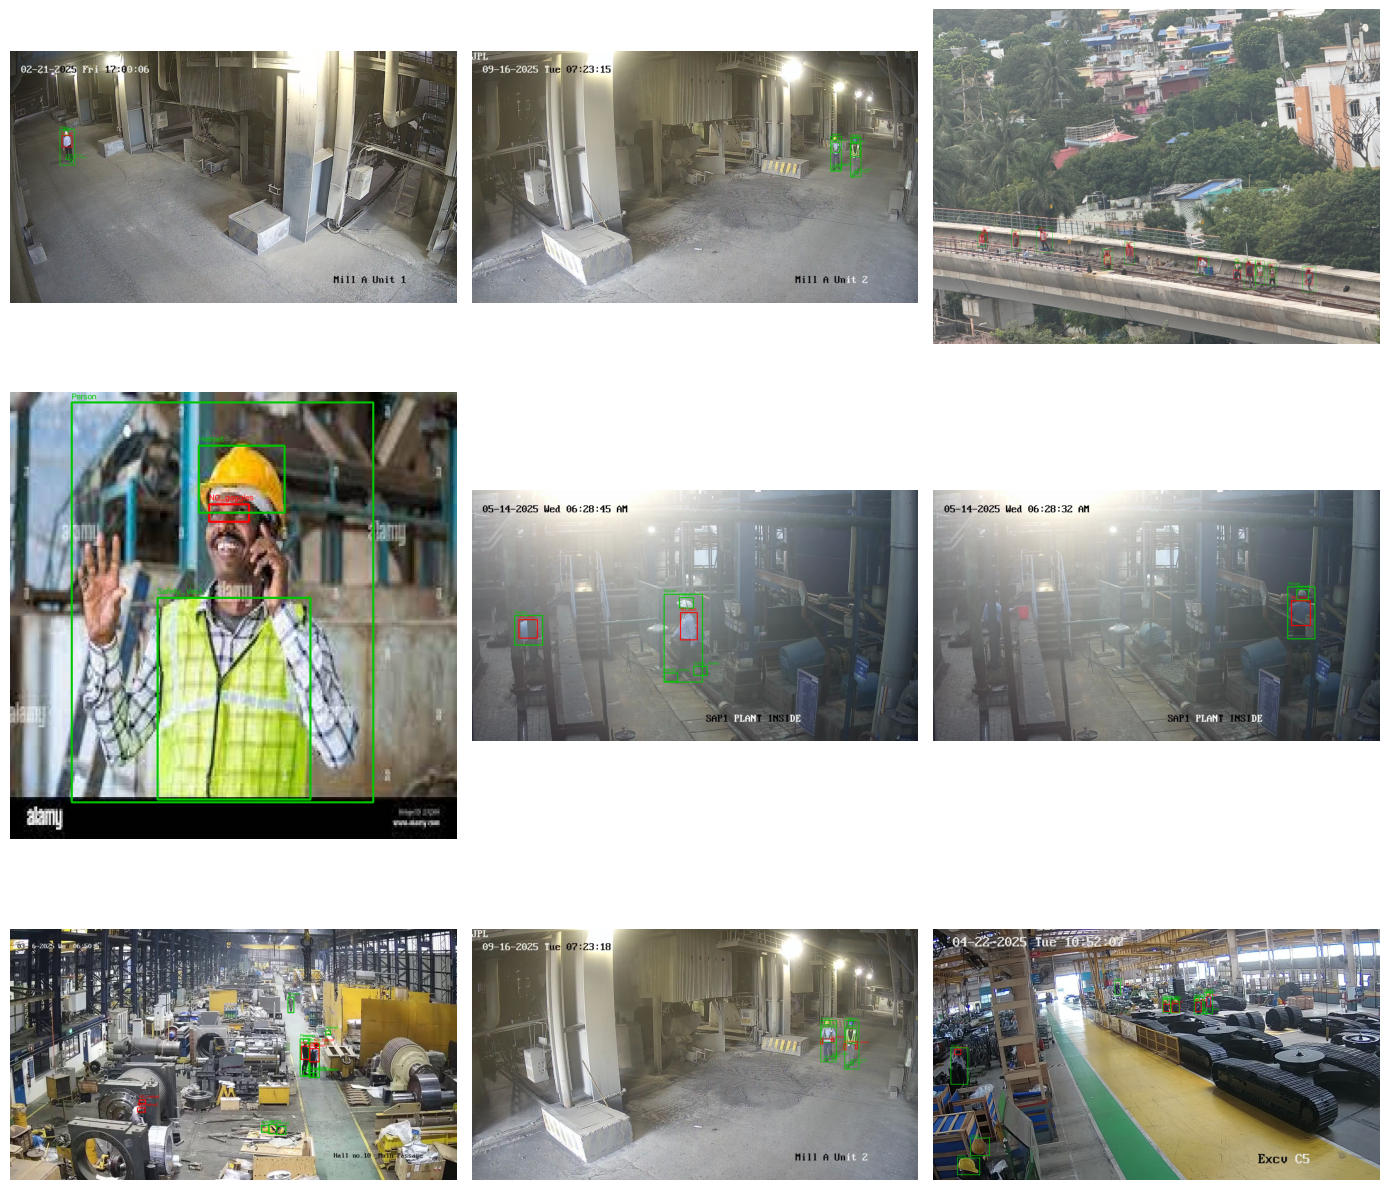

In [44]:
import random

random.seed(42)

def draw_boxes(image_path, label_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    with open(label_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    for line in lines:
        parts = line.split()
        cls_id = int(parts[0])
        xc, yc, bw, bh = map(float, parts[1:5])
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        color = (255, 0, 0) if "NO" in CLASS_NAMES[cls_id] else (0, 200, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, CLASS_NAMES[cls_id], (x1, max(y1 - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    return img

train_images = list_images("train")
sample = random.sample(train_images, min(9, len(train_images)))

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
for ax, img_path in zip(axes.flat, sample):
    base = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(DATA_ROOT, "train", "labels", base + ".txt")
    if os.path.exists(label_path):
        img = draw_boxes(img_path, label_path)
        ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 9. EDA conclusions

(to be filled in manually, based on the results above, before moving to Step 4)

* **Total number of images / train-val-test distribution:** 15,522 images total.
  Originally split 70/20/10 (train/val/test). Re-split in Step 6 to 90/10 between
  train and val (12,573 / 1,397), while keeping the original test set (1,552 images)
  completely untouched.

* **Class imbalance observed:** significant imbalance across the 11 classes.
  `Helmet`, `Person`, and `NO_Vest` are heavily over-represented, while
  `Safety_goggles`, `NO_Gloves`, and `Slippers` have very few examples
  (tens to low hundreds of instances vs. thousands for the dominant classes).

* **Data quality issues found:** no real structural issues once extension bugs
  were fixed. Initially, `.webp` and `.jfif` images were not recognized by the
  `list_images()` function, producing false "orphan label" counts. Separately,
  `.jfif` files were found to be silently skipped by Ultralytics during actual
  training (not in its supported `IMG_FORMATS` list) and were renamed to `.jpg`.
  ~63 empty label files (images with no annotated objects) were kept as valid
  negative samples rather than removed.

* **Classes with very small objects (potentially hard to detect):**
  `Safety_goggles` stands out - both from the bounding box area analysis
  (smallest median area of all classes) and from actual training results,
  where it consistently shows the lowest mAP50 (~0.05-0.13) of all classes.

* **Resulting decisions for the next steps (augmentation, loss weighting, etc.):**
  - Re-split train/val to 90/10 (Step 6, done) to give the model more training data
    while keeping a stable, untouched test set for final evaluation.
  - Consider class-balanced sampling or loss weighting for the underrepresented
    classes (`Safety_goggles`, `NO_Gloves`, `Slippers`) in Step 7.
  - Consider testing a larger `imgsz` (e.g. 640 instead of 416) in Step 7, since
    small objects like `Safety_goggles` may benefit from higher input resolution.
  - Early stopping (`patience=10`) is especially useful here, since classes with
    few examples are prone to overfitting quickly.